# Notebook 02 — Prototipo SAM2 con detectores externos

Este notebook prueba el pipeline **detector → segmentador** sobre un frame ya preprocesado:

```
frame limpio  ──▶  DETECTOR  ──▶  posiciones (puntos o cajas)  ──▶  SAM2  ──▶  máscaras
```

## ¿Por qué SAM2 necesita un detector adelante?

**SAM2 es un SEGMENTADOR, no un detector.** Dada una posición (un punto o una caja), dibuja el contorno del objeto que está ahí. Pero **no decide por sí mismo dónde buscar objetos** — hay que decírselo.

Esto es importante de entender: si le mostrás a SAM2 una foto de la calle y no le decís nada, no te devuelve "acá hay un auto, acá un peatón". Te exige un prompt visual: "mirá en este punto" o "mirá en esta caja".

## Los dos detectores que vamos a probar

| Detector           | Tipo                    | Qué le decimos                      | Salida                  |
| ------------------ | ----------------------- | ----------------------------------- | ----------------------- |
| **blob_log**       | Clásico (LoG, anios 90) | Tamanio del blob (sigma)            | Lista de (y, x, sigma)  |
| **Grounding DINO** | Deep learning (2023)    | Texto: "small fluorescent particle" | Lista de bounding boxes |

Después le pasamos las posiciones detectadas a SAM2 y dibuja los contornos.

## Diferencia con SAM3

SAM3 (notebook 03) **internaliza el detector** y acepta texto directamente, sin necesidad de Grounding DINO adelante. Este notebook es el caso clásico previo a SAM3.


---

## Setup

Cargamos un frame, lo pasamos por el pipeline del notebook 01, y dejamos `frame_rgb` listo para los modelos.


In [25]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.ets_reader import encontrar_ets, leer_header_ets, leer_frame
from axonal_tracking import preprocesamiento as pp
from axonal_tracking import visualizacion as viz
from axonal_tracking import configuracion as cfg

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Configuracion compartida (escrita por el notebook 01).
# Editá data/configuracion_actual.yaml o el dict CONFIG del notebook 01 para
# cambiar video / frame / modo de procesamiento.
config = cfg.cargar_configuracion()
VIDEO = config["video"]["ruta"]
ROI = config["video"]["roi"]
FRAME_IDX = config["frames"]["demo"]
MODO = config["procesamiento"]["modo"]
print(f"Config: video={VIDEO.name}, frame={FRAME_IDX}, modo={MODO}")

ets = encontrar_ets(VIDEO)
info = leer_header_ets(ets)
frame_u16 = leer_frame(info, FRAME_IDX)

# Pipeline de preprocesamiento segun el modo configurado.
# En modo "rgb_crudo" no se calcula fondo temporal.
fondo_temporal = None
if MODO != "rgb_crudo":
    n_contexto = config["procesamiento"]["parametros"].get("n_frames_temporal", 10)
    subvideo = np.stack([leer_frame(info, i) for i in range(n_contexto)])
    fondo_temporal = pp.calcular_fondo_temporal(subvideo, metodo="mediana")
    print(f"Contexto temporal: {n_contexto} frames, fondo shape={fondo_temporal.shape}")

pasos = cfg.aplicar_modo_frame(frame_u16, config, fondo_temporal=fondo_temporal)
frame_rgb = pasos["rgb_uint8"]
frame_pil = Image.fromarray(frame_rgb)

# Para blob_log usamos el frame "limpio" (no el RGB). En modo rgb_crudo,
# pasos["sin_ruido"] es el mismo frame uint16 sin procesar — sigue siendo
# valido como entrada del detector LoG.
frame_limpio = pasos["sin_ruido"]

print(f"Frame listo: shape={frame_rgb.shape}, dtype={frame_rgb.dtype}")

Device: mps
Config: video=Movie_674.vsi, frame=0, modo=configurable
Contexto temporal: 10 frames, fondo shape=(1148, 1279)
Frame listo: shape=(1148, 1279, 3), dtype=uint8


---

## Carga del modelo SAM2.1

Descargamos los pesos preentrenados desde Hugging Face. La variante `base-plus` es un buen balance entre velocidad y calidad para correr en MPS/CPU.

Primera ejecución: ~325 MB de descarga (queda cacheado en `~/.cache/huggingface/`).


In [26]:
from transformers import Sam2Processor, Sam2Model

MODEL_ID = "facebook/sam2.1-hiera-base-plus"
print(f"Cargando {MODEL_ID}...")
processor_sam2 = Sam2Processor.from_pretrained(MODEL_ID)
model_sam2 = Sam2Model.from_pretrained(MODEL_ID).to(device).eval()
n_params = sum(p.numel() for p in model_sam2.parameters()) / 1e6
print(f"OK — SAM2.1 cargado en {device} ({n_params:.0f} M parametros)")

Cargando facebook/sam2.1-hiera-base-plus...


[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

OK — SAM2.1 cargado en mps (73 M parametros)


---

## Enfoque A — blob_log + SAM2

El detector clásico **Laplacian of Gaussian** (`skimage.feature.blob_log`) busca _manchas brillantes de un tamanio específico_. Le decimos "buscame puntos de σ entre 1 y 3 px" (eso es el tamanio típico de una vesícula) y nos devuelve coordenadas `(y, x, σ)`.

Después pasamos esas coordenadas como **prompts visuales** a SAM2 — un punto por vesícula detectada — y SAM2 segmenta lo que encuentra alrededor de cada punto.


In [27]:
from skimage.feature import blob_log

# Normalizamos para que el threshold de blob_log sea interpretable.
f_norm = frame_limpio / frame_limpio.max() if frame_limpio.max() > 0 else frame_limpio

blobs = blob_log(
    f_norm,
    min_sigma=1,
    max_sigma=3,
    num_sigma=5,
    threshold=0.05,
)
print(f"blob_log encontro {len(blobs)} blobs.")

# Para no saturar SAM2 en MPS, nos quedamos con los N mas intensos.
N_MAX = 30
intensidades = np.array([frame_limpio[int(y), int(x)] for y, x, _ in blobs])
orden = np.argsort(intensidades)[::-1][:N_MAX]
blobs_top = blobs[orden]
print(f"Pasamos los {len(blobs_top)} mas intensos a SAM2.")

blob_log encontro 41 blobs.
Pasamos los 30 mas intensos a SAM2.


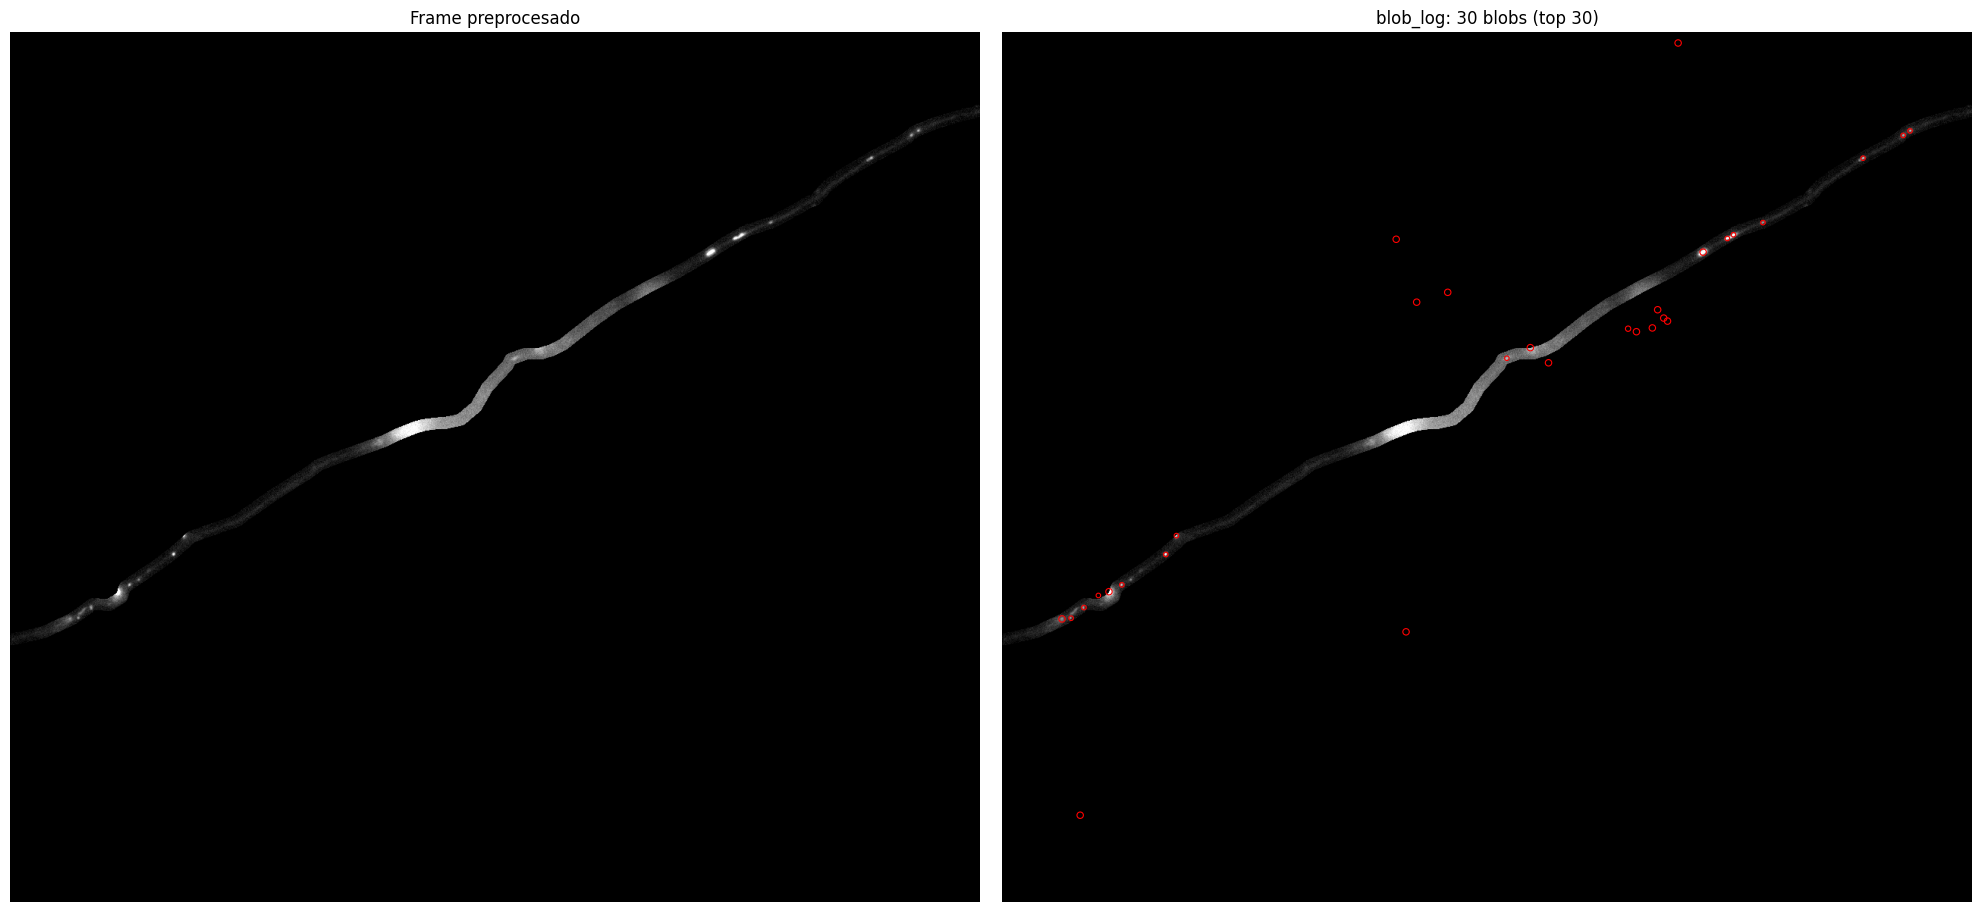

In [28]:
# Visualizamos los blobs ANTES de pasar a SAM2.
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.dibujar_blobs(frame_rgb, blobs_top, ax=ax1)
ax1.set_title(f"blob_log: {len(blobs_top)} blobs (top {N_MAX})")
plt.tight_layout()
plt.show()

In [29]:
# Convertimos los blobs a prompts visuales de SAM2.
# Formato esperado: 4 niveles [imagen, objeto, punto, [x, y]]
# Tratamos cada blob como un objeto separado con 1 punto positivo.
input_points_a = [[[[int(x), int(y)]] for y, x, _ in blobs_top]]
input_labels_a = [[[1] for _ in blobs_top]]

inputs_a = processor_sam2(
    images=frame_pil,
    input_points=input_points_a,
    input_labels=input_labels_a,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs_a = model_sam2(**inputs_a)

masks_a = processor_sam2.post_process_masks(
    outputs_a.pred_masks.cpu(),
    original_sizes=[(frame_pil.size[1], frame_pil.size[0])],
    reshaped_input_sizes=inputs_a.get("reshaped_input_sizes", None),
)[0]
iou_a = outputs_a.iou_scores.cpu()

# Tomamos la hipotesis de mayor IoU por objeto.
m_arr_a = masks_a.numpy()
if m_arr_a.ndim == 4:
    # Tomamos la hipotesis de mayor IoU por objeto, manera robusta a N=1.
    iou_np = iou_a.numpy().reshape(m_arr_a.shape[0], -1)
    best = iou_np.argmax(axis=-1)
    m_arr_a = np.stack([m_arr_a[i, int(best[i])] for i in range(m_arr_a.shape[0])])

print(f"SAM2 devolvio {len(m_arr_a)} mascaras (una por blob).")

SAM2 devolvio 30 mascaras (una por blob).


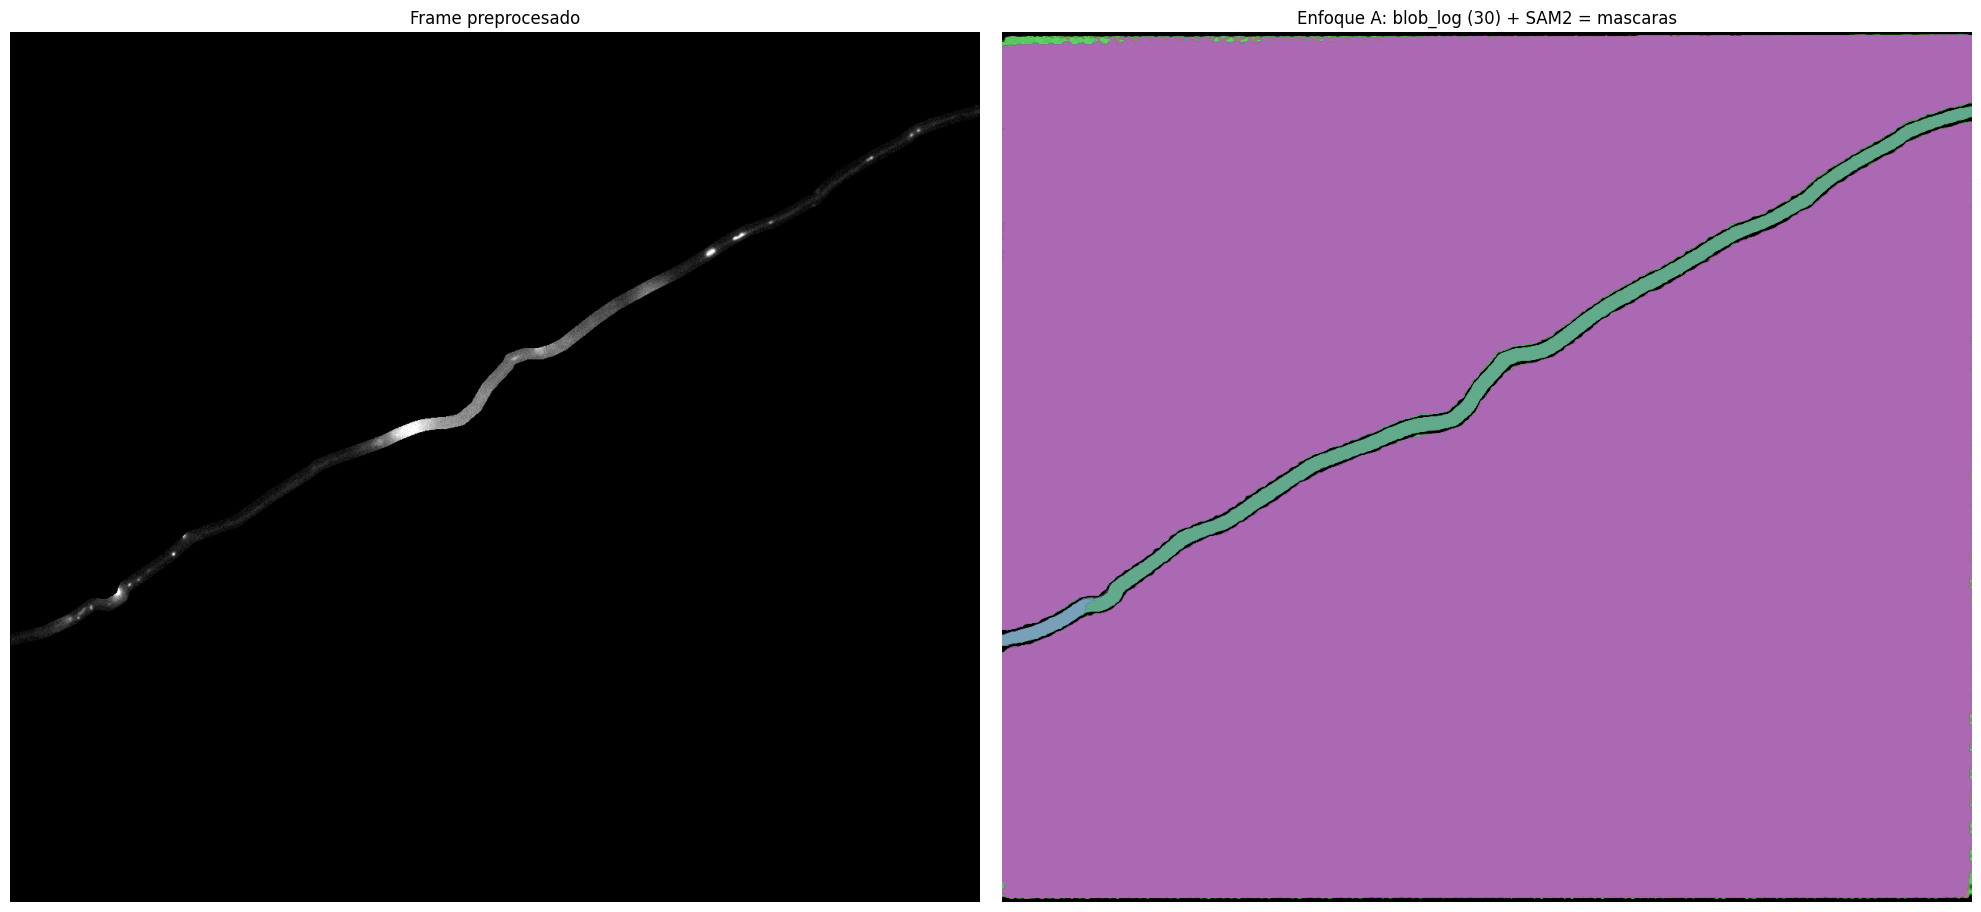

In [30]:
# Visualizacion: blobs + mascaras de SAM2.
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_a, ax=ax1)
ax1.set_title(f"Enfoque A: blob_log ({len(blobs_top)}) + SAM2 = mascaras")
plt.tight_layout()
plt.show()

**Observaciones del enfoque A:**

- `blob_log` encuentra todos los puntitos brillantes — incluye vesículas reales pero también agregados grandes.
- SAM2 segmenta bien los blobs compactos. Sufre cuando los blobs son muy chicos (~2 px) — devuelve máscaras puntuales o nada.
- La calidad final depende casi enteramente de la calidad de `blob_log` ("garbage in, garbage out").


---

## Enfoque B — Grounding DINO + SAM2

**Grounding DINO** (IDEA-Research, 2023) es un detector _open-vocabulary_: le pasás texto en lenguaje natural y devuelve bounding boxes. Es el detector que se suele combinar con SAM ("Grounded SAM") cuando no querés escribir reglas a mano ni etiquetar datos.

El flujo es:

```
frame + texto "small fluorescent particle"
    │
    ▼
Grounding DINO  →  [bounding boxes con scores]
    │
    ▼
SAM2 con cajas  →  máscaras
```

Primera carga del modelo: ~700 MB.


In [31]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DINO_ID = "IDEA-Research/grounding-dino-tiny"
print(f"Cargando {DINO_ID}...")
processor_dino = AutoProcessor.from_pretrained(DINO_ID)
model_dino = (
    AutoModelForZeroShotObjectDetection.from_pretrained(DINO_ID).to(device).eval()
)
n_params_dino = sum(p.numel() for p in model_dino.parameters()) / 1e6
print(f"OK — Grounding DINO cargado en {device} ({n_params_dino:.0f} M parametros)")

Cargando IDEA-Research/grounding-dino-tiny...


Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

OK — Grounding DINO cargado en mps (172 M parametros)


In [32]:
# Pasamos el frame + texto al detector.
# El texto debe terminar con un punto y todo en minuscula (convencion de Grounding DINO).
TEXTO_PROMPT = "small fluorescent particle."
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.20

# Le pasamos a GDINO el frame ANTES del enmascarado del ROI, asi tiene mas
# estructura visual. Despues filtramos las cajas que caen fuera del ROI.
frame_rgb_completo = pp.frame_a_rgb_uint8(pasos["sin_ruido"])
frame_pil_completo = Image.fromarray(frame_rgb_completo)

inputs_dino = processor_dino(
    images=frame_pil_completo, text=TEXTO_PROMPT, return_tensors="pt"
).to(device)
with torch.no_grad():
    outputs_dino = model_dino(**inputs_dino)

# Post-procesado: convierte salidas crudas en cajas con scores y etiquetas.
resultados_dino = processor_dino.post_process_grounded_object_detection(
    outputs_dino,
    inputs_dino.input_ids,
    threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
    target_sizes=[(frame_pil.size[1], frame_pil.size[0])],
)[0]

boxes_dino = resultados_dino["boxes"].cpu().numpy()
scores_dino = resultados_dino["scores"].cpu().numpy()
print(
    f'Grounding DINO con texto "{TEXTO_PROMPT}" detecto {len(boxes_dino)} cajas totales.'
)

# Filtros: tamano (< 5% del frame) y dentro del ROI (si hay mascara).
H, W = frame_rgb.shape[:2]
area_frame = H * W
MAX_AREA_FRAC = 0.05
areas = np.array([(b[2] - b[0]) * (b[3] - b[1]) / area_frame for b in boxes_dino])
mask_chicas = areas < MAX_AREA_FRAC

if pasos["mascara_roi"] is not None:
    mascara = pasos["mascara_roi"]
    MIN_OVERLAP_ROI = 0.3

    def caja_en_roi(box):
        x1, y1, x2, y2 = [int(v) for v in box]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 <= x1 or y2 <= y1:
            return False
        recorte = mascara[y1:y2, x1:x2]
        return recorte.sum() / recorte.size > MIN_OVERLAP_ROI

    mask_roi = (
        np.array([caja_en_roi(b) for b in boxes_dino])
        if len(boxes_dino)
        else np.array([], dtype=bool)
    )
else:
    mask_roi = np.ones(len(boxes_dino), dtype=bool)

mask_total = mask_chicas & mask_roi
boxes_dino = boxes_dino[mask_total]
scores_dino = scores_dino[mask_total]
print(f"Tras filtros: {len(boxes_dino)} cajas.")
if len(scores_dino) > 0:
    print(
        f"  Scores: min={scores_dino.min():.2f}, max={scores_dino.max():.2f}, mean={scores_dino.mean():.2f}"
    )

Grounding DINO con texto "small fluorescent particle." detecto 1 cajas totales.
Tras filtros: 0 cajas.


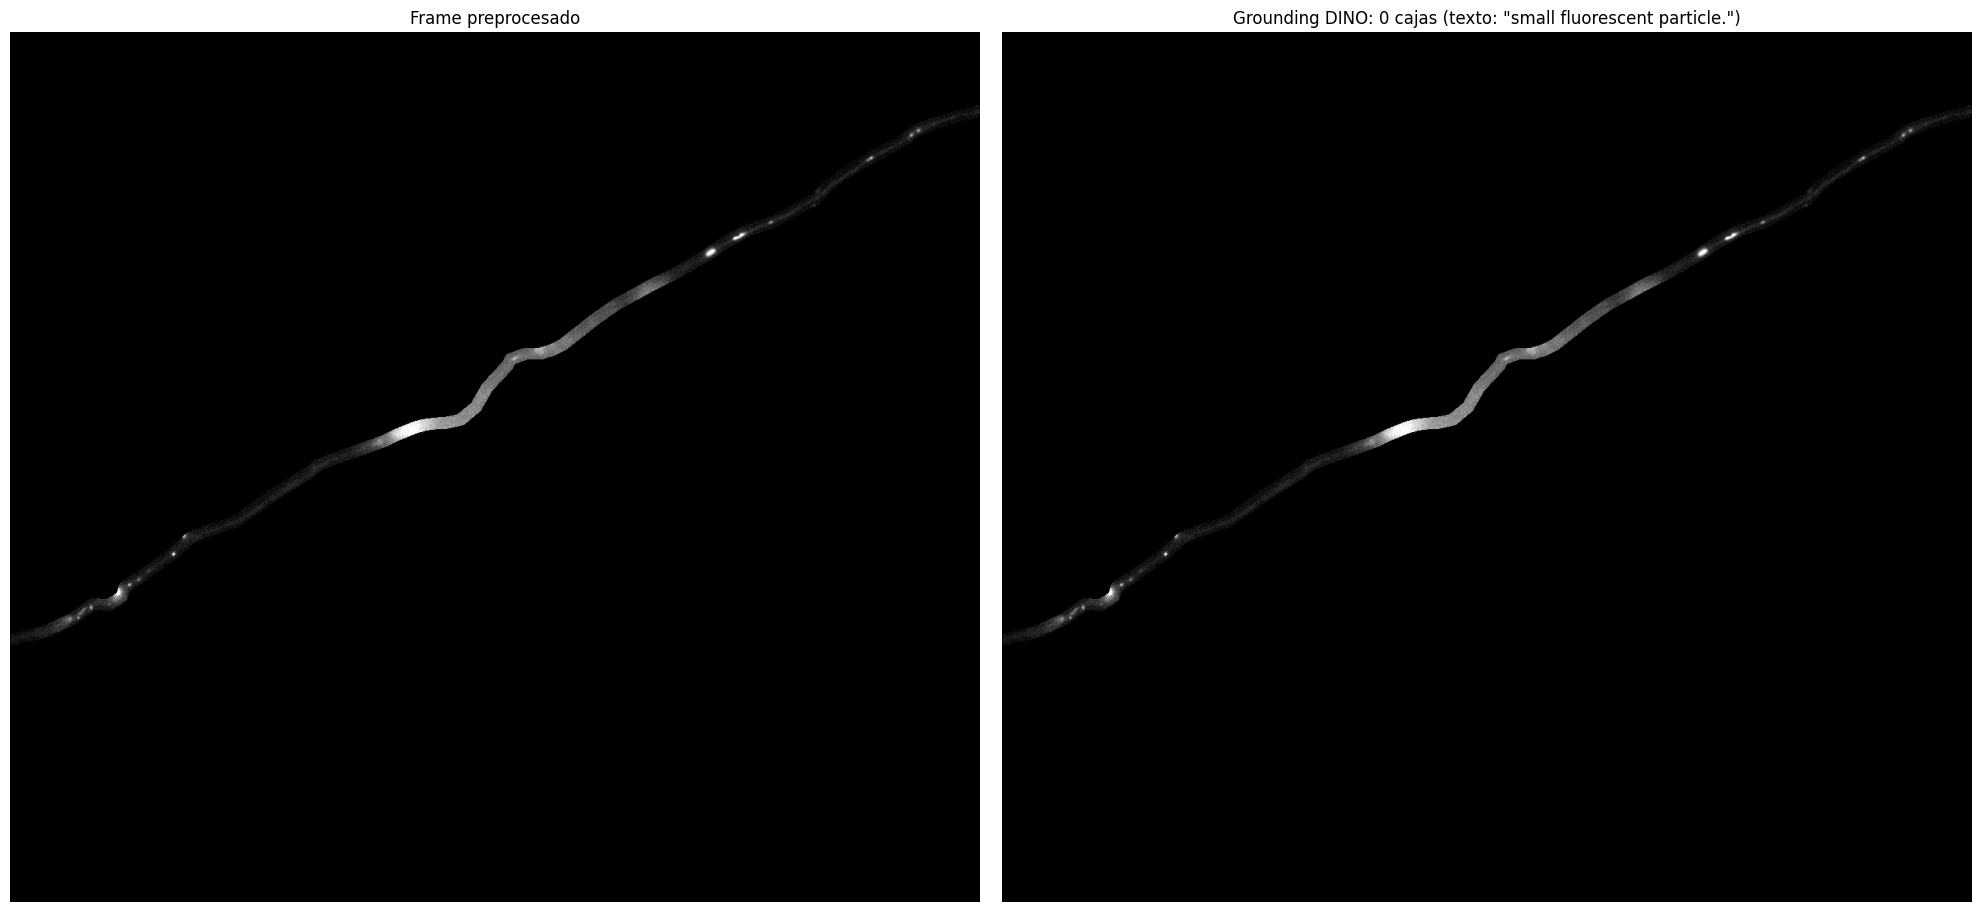

In [33]:
# Visualizamos las cajas que devolvio Grounding DINO.
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.dibujar_cajas(
    frame_rgb,
    boxes_dino,
    ax=ax1,
    labels=[f"{s:.2f}" for s in scores_dino],
)
ax1.set_title(f'Grounding DINO: {len(boxes_dino)} cajas (texto: "{TEXTO_PROMPT}")')
plt.tight_layout()
plt.show()

In [34]:
# Pasamos las cajas a SAM2 como prompts.
# Formato: [imagen, objeto, [x1, y1, x2, y2]]
if len(boxes_dino) > 0:
    input_boxes_b = [boxes_dino.tolist()]

    inputs_b = processor_sam2(
        images=frame_pil,
        input_boxes=input_boxes_b,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs_b = model_sam2(**inputs_b)

    masks_b = processor_sam2.post_process_masks(
        outputs_b.pred_masks.cpu(),
        original_sizes=[(frame_pil.size[1], frame_pil.size[0])],
        reshaped_input_sizes=inputs_b.get("reshaped_input_sizes", None),
    )[0]
    iou_b = outputs_b.iou_scores.cpu()

    m_arr_b = masks_b.numpy()
    if m_arr_b.ndim == 4:
        # m_arr_b shape: (n_objetos, n_hipotesis, H, W)
        # Tomamos la hipotesis de mayor IoU por cada objeto.
        if iou_b is not None:
            # Aplanar iou a (n_objetos, n_hipotesis) sin importar la forma original
            iou_np = iou_b.numpy().reshape(m_arr_b.shape[0], -1)
            best = iou_np.argmax(axis=-1)
        else:
            best = np.zeros(m_arr_b.shape[0], dtype=int)
        m_arr_b = np.stack([m_arr_b[i, int(best[i])] for i in range(m_arr_b.shape[0])])

    print(f"SAM2 devolvio {len(m_arr_b)} mascaras (una por caja de DINO).")
else:
    m_arr_b = np.zeros((0, *frame_rgb.shape[:2]), dtype=bool)
    print("Grounding DINO no detecto nada — no hay nada que pasar a SAM2.")

Grounding DINO no detecto nada — no hay nada que pasar a SAM2.


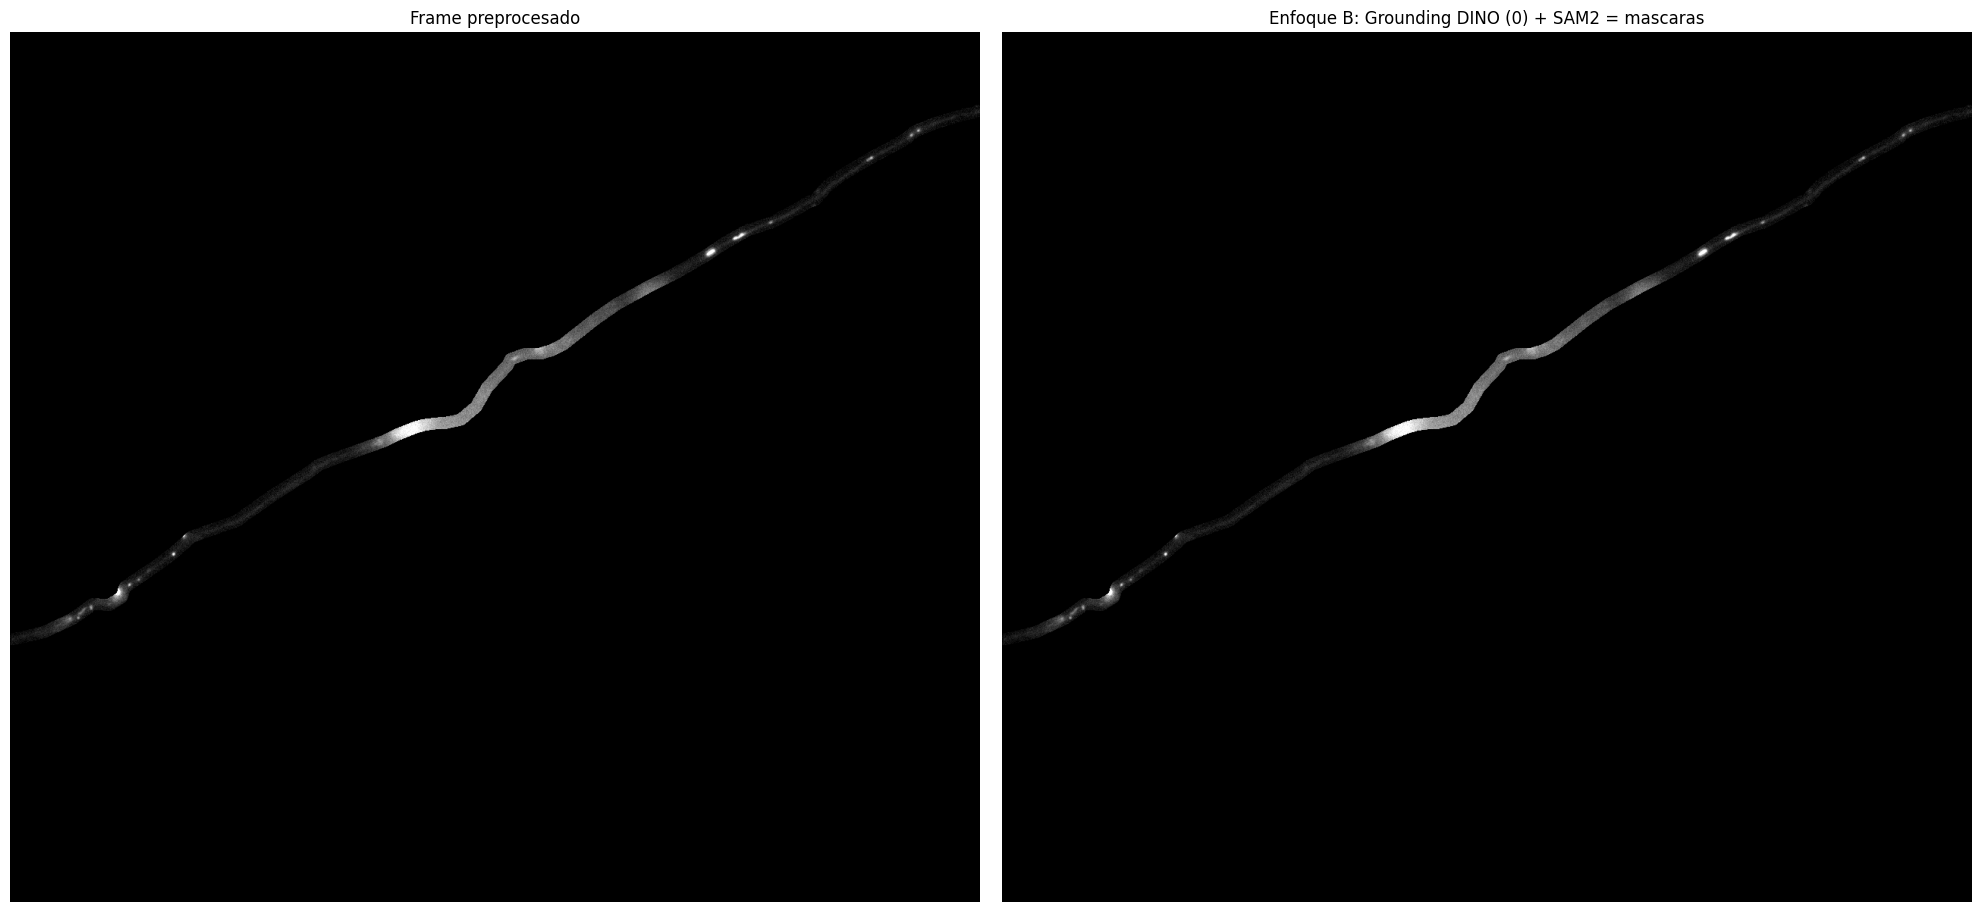

In [35]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 9))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=ax0)
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=ax1)
ax1.set_title(f"Enfoque B: Grounding DINO ({len(m_arr_b)}) + SAM2 = mascaras")
plt.tight_layout()
plt.show()

**Observaciones del enfoque B:**

- Grounding DINO probablemente devuelve **pocas cajas** (o ninguna): fue entrenado sobre imágenes naturales (gente, autos, animales). "Small fluorescent particle" está completamente fuera de su distribución.
- Cuando detecta algo, suele ser un cluster grande (un grupo de vesículas, no una sola).
- Es esperable que este enfoque rinda peor que `blob_log + SAM2` para este caso de uso.
- Vale la pena probar otras frases (`"bright dot"`, `"vesicle"`, `"fluorescent spot"`) — el detector es sensible a la elección de palabras.


---

## Comparación final: A vs B

Lado a lado para tener una idea cualitativa.


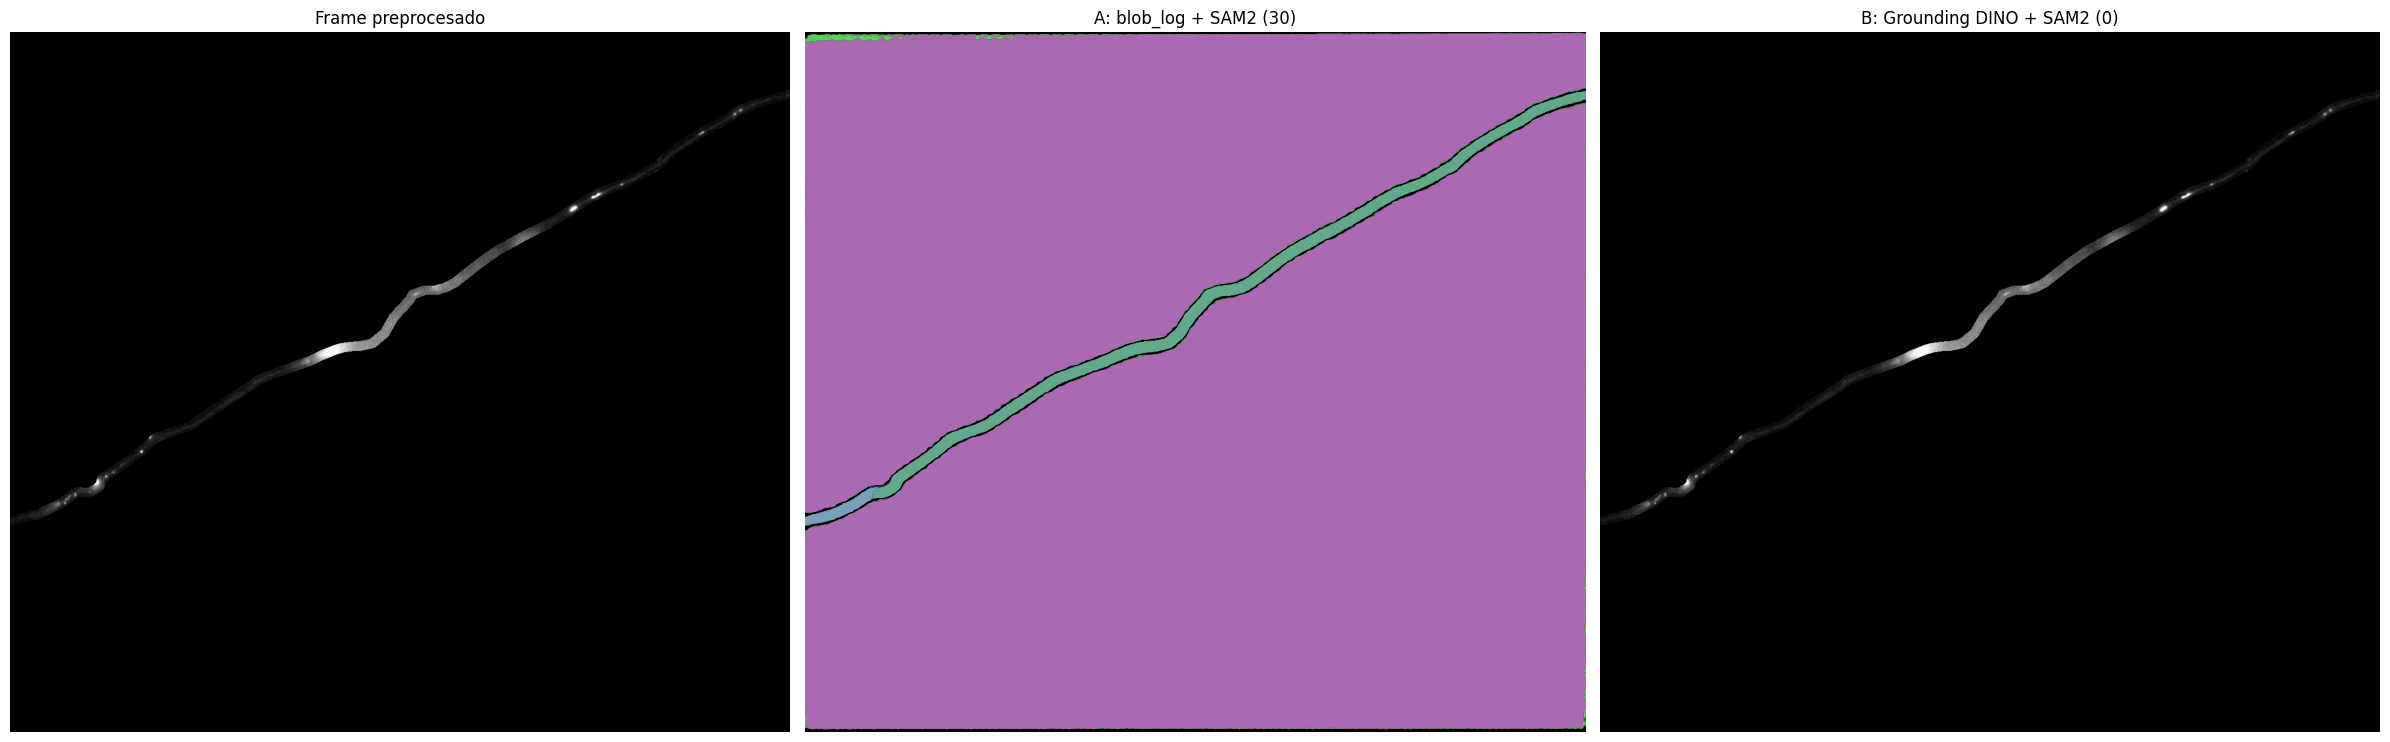

Resumen — Enfoque A (blob_log)        : 30 mascaras
        — Enfoque B (Grounding DINO)  : 0 mascaras


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
viz.mostrar_frame(frame_rgb, "Frame preprocesado", ax=axes[0])
viz.overlay_mascaras(frame_rgb, m_arr_a, ax=axes[1])
axes[1].set_title(f"A: blob_log + SAM2 ({len(m_arr_a)})")
viz.overlay_mascaras(frame_rgb, m_arr_b, ax=axes[2])
axes[2].set_title(f"B: Grounding DINO + SAM2 ({len(m_arr_b)})")
plt.tight_layout()
plt.show()

print(f"Resumen — Enfoque A (blob_log)        : {len(m_arr_a)} mascaras")
print(f"        — Enfoque B (Grounding DINO)  : {len(m_arr_b)} mascaras")

---

## Próximos pasos

Este notebook quedó en **frame único** y **detección + segmentación**. Para ir al objetivo final del proyecto faltaría:

1. **Tracking en video**: SAM2 tiene un modo video (`Sam2VideoModel`) que propaga las máscaras del frame 0 a los siguientes manteniendo la identidad. Eso convierte detecciones por frame en _tracks_ (trayectorias de vesículas en el tiempo).
2. **Detector específico de dominio**: si Grounding DINO sufre con vesículas, una opción es **fine-tunear YOLO11** con 50–200 vesículas etiquetadas a mano. Esto suele dar el mejor resultado.
3. **Cuantificación**: medir velocidades (µm/s) usando [parametros.py](../src/axonal_tracking/parametros.py) (`PIXEL_SIZE_UM`, `segundos_por_frame`) y comparar contra el ground truth manual de los `.xlsx`.

## Comparación con el notebook 03

En **[03_sam3_prototipo.ipynb](03_sam3_prototipo.ipynb)** repetimos los mismos dos enfoques pero usando SAM3 como segmentador, **y además** sumamos un tercer enfoque donde SAM3 hace detección + segmentación en una sola pasada usando texto (sin necesidad de Grounding DINO adelante). Es la novedad principal de SAM3 vs SAM2.
